# Amazon US Customer Reviews: Data Exploration

This notebook explores the data in the [Amazon US Customer Reviews](https://www.kaggle.com/datasets/cynthiarempel/amazon-us-customer-reviews-dataset) dataset sourced from Kaggle. The dataset is approximately 50.68 GB and contains over 109 million rows across dozens of product categories. We examine the data structure, distributions, missing values, duplicates, and key relationships between review attributes.

## Setup and Imports

In [2]:
from pyspark.sql import SparkSession, SQLContext
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
from pyspark.sql import SQLContext
from pyspark.sql.functions import col, length, round, expr, sum as spark_sum
from pyspark.ml.feature import Imputer, StringIndexer, VectorAssembler

## Spark Session Configuration

Our SDSC Expanse allocation provides 16 total cores and 128 GB total memory. The dataset is 50.68 GB across 37 Parquet files. 

In [3]:
import subprocess, os
USER = os.getenv("USER")
subprocess.run(["mkdir", "-p", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp"])

CompletedProcess(args=['mkdir', '-p', '/expanse/lustre/projects/uci157/kzhu8/spark_tmp'], returncode=0)

In [4]:
spark = SparkSession.builder \
    .config("spark.driver.memory","4g") \
    .config("spark.executor.memory", "15g") \
    .config('spark.executor.instances', 7) \
    .config("spark.executor.cores", "2") \
    .config("spark.sql.shuffle.partitions", "400") \
    .config("spark.local.dir", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp") \
    .config("spark.sql.parquet.columnarReaderBatchSize", "512") \
    .getOrCreate()

spark

### Executor Verification

In [5]:
# Get the active Spark Context, URL, and SQL Context
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"
sqlContext = SQLContext(spark.sparkContext)

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
spd = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
spd['maxMemory_GB'] = (spd['maxMemory'] / (1024**3)).round(2)
spd

/usr/local/spark/python/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,16,2388236697,0,True,2.22


### Current Spark Configuration

In [6]:
print("Executor Instances:", sc.getConf().get("spark.executor.instances"))
print("Executor Memory:", sc.getConf().get("spark.executor.memory"))
print("Driver Memory:", sc.getConf().get("spark.driver.memory"))
print("Executor Cores:", sc.getConf().get("spark.executor.cores"))
print("Total Cores Available:", sc._jsc.sc().defaultParallelism())

Executor Instances: 7
Executor Memory: 15g
Driver Memory: 4g
Executor Cores: 2
Total Cores Available: 16


## Data Loading

In [7]:
# Load the data into Spark dataframe
parquet_path = r"/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews.parquet"
df = spark.read.parquet(parquet_path)

## 1. Complete Preprocessing using Spark (8 points)

### 1) Clean below invalid data (Anuradha)
1. Product category has invalid data like dates and reviews.
2. Star ratings has Null and dates
3. Null records in "review_id", "review_body", "review_headline", "review_date" and "product_category"
4. Duplicate review ids. Reviews have to be unique for analysis

In [8]:
def filter_invalid_categories(df):
    valid_categories = [
        "Wireless", "PC", "Mobile_Apps", "Digital_Ebook_Pur...", "Video DVD",
        "Apparel", "Music", "Health & Personal...", "Beauty", "Digital_Video_Dow...",
        "Toys", "Sports", "Shoes", "Books", "Automotive", "Electronics",
        "Office Products", "Pet Products", "Grocery", "Outdoors", "Camera",
        "Video Games", "Digital_Music_Pur...", "Baby", "Tools", "Watches",
        "Musical Instruments", "Furniture", "Video", "Software", "Gift Card",
        "Digital_Video_Games", "Mobile_Electronics", "Digital_Software",
        "Major Appliances", "Personal_Care_App...", "Home Entertainment",
        "Home Improvement", "Home", "Kitchen", "Lawn and Garden", "Luggage"
    ]
    return df.filter(col("product_category").isin(valid_categories))


def filter_invalid_star_ratings(df):
    valid_ratings = [1, 2, 3, 4, 5]
    return df.withColumn("star_rating", col("star_rating").cast("int")) \
             .withColumn("helpful_votes", col("helpful_votes").cast("int")) \
             .withColumn("total_votes", col("total_votes").cast("int")) \
             .filter(col("star_rating").isin(valid_ratings))


def drop_null_records(df):
    required_columns = ["review_id", "review_body", "review_headline", "review_date", "product_category"]
    return df.dropna(subset=required_columns)


def drop_duplicate_reviews(df):
    return df.dropDuplicates(["review_id"])

def impute_missing_values(df):
    imputer = Imputer(
        strategy="median",
        inputCols=["star_rating", "helpful_votes", "total_votes"],
        outputCols=["star_rating", "helpful_votes", "total_votes"]
    )
    return imputer.fit(df).transform(df)

In [9]:
def cleansing1(df):
    df = filter_invalid_categories(df)
    df = filter_invalid_star_ratings(df)
    df = drop_null_records(df)
    df = drop_duplicate_reviews(df)
    df = impute_missing_values(df)
    return df

### 2) Numerical Encoding (Matthew)

- Cast star_rating from String to Integer for numerical processing. (Just in case we calculate the mean or so)
- Apply StringIndexer to encode categorical variables (verified_purchase, vine) into binary (0/1).

In [10]:
def cleansing2(df):
    df = df.withColumn("star_rating", col("star_rating").cast("int"))
    df = df.withColumn("review_headline_length", length(col("review_headline")))
    
    indexer_vp = StringIndexer(inputCol="verified_purchase", outputCol="verified_purchase_idx", handleInvalid="keep")
    df = indexer_vp.fit(df).transform(df)
    
    category_indexer = StringIndexer(
        inputCol="product_category", outputCol="category_idx", handleInvalid="keep"
    )
    df = category_indexer.fit(df).transform(df)

    return df

### 3) Text Analytics & Scaling (Hana)

- Compute review_length using the length() function on the review_body column.
- Implement StandardScaler or MinMaxScaler to normalize numerical features for better model convergence.
- (Optional) Prepare a Tokenizer for potential text-based model expansion in Milestone 4.

In [11]:
from pyspark.ml.feature import MinMaxScaler, Tokenizer

def cleansing3(df):
    df = df.withColumn("review_length", length(col("review_body")))
    # numeric_cols = ["star_rating", "helpful_votes", "total_votes", "review_length"]
    # assembler = VectorAssembler(inputCols=numeric_cols, outputCol="numeric_features", handleInvalid="skip")
    # df = assembler.transform(df)

    # scaler = MinMaxScaler(inputCol="numeric_features", outputCol="scaled_features")
    # df = scaler.fit(df).transform(df)
    
    tokenizer = Tokenizer(inputCol="review_body", outputCol="review_tokens")
    df = tokenizer.transform(df)

    return df

### 4) Target Engineering & Sampling (Kayla)

- Calculate the target variable: helpfulness_ratio (helpful_votes / total_votes) for rows where total_votes > 0
- Create other new features using Spark SQL functions (log of helpful vote, log of total votes, log of review length)
- Implement sampleBy() for Stratified Sampling to address the heavy skew toward 5-star ratings
- Perform the final Train/Validation/Test split (e.g., 80/10/10) for model evaluation.

In [12]:
from pyspark.sql.functions import when, log1p

def cleansing4(df):
    # Target variable
    df = df.filter(col("total_votes") > 0)
    df = df.withColumn("helpfulness_ratio", col("helpful_votes") / col("total_votes"))
    df = df.withColumn("label",
        when(col("helpful_votes") / col("total_votes") >= 0.5, 1.0).otherwise(0.0)
    )
    # Feature engineering using Spark SQL functions
    df = df.withColumn("log_helpful_votes", log1p(col("helpful_votes")))
    df = df.withColumn("log_total_votes", log1p(col("total_votes")))
    df = df.withColumn("log_review_length", log1p(col("review_length")))

    # Stratified Sampling
    fractions = {1: 0.6, 2: 1.0, 3: 0.67, 4: 0.32, 5: 0.09}
    df = df.sampleBy("star_rating", fractions=fractions, seed=42)
    return df

### Pipelines

In [21]:
# df_clean.write.mode("overwrite").parquet("/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews_clean.parquet")

In [18]:
#=== df_clean is stored in "/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews_clean.parquet". No need to run this cell ===
checkpoint_dir = "/expanse/lustre/projects/uci157/hkwon2/spark_checkpoints"
spark.sparkContext.setCheckpointDir(checkpoint_dir)

df_clean = cleansing4(cleansing3(cleansing2(cleansing1(df)))).checkpoint()

---
### Checking Codes (you are free to code anything to check if your or our works are valid.)

In [ ]:
# Check Product Categories after removing invalid data
df_filtered2.groupBy("product_category") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(50)

Invalid product categories have been filtered out

In [ ]:
# Check Star ratings after removing invalid data
df_filtered2.groupBy("star_rating") \
  .count() \
  .orderBy("star_rating") \
  .show(50)

In [ ]:
df_filtered4.select("helpful_score").show(10)

In [ ]:
df_helpfulness_ratio =  df_filtered4.select("helpfulness_ratio").toPandas()

plt.figure(figsize=(10,5))
plt.hist(df_helpfulness_ratio, bins=11, color="steelblue", edgecolor="white")
plt.tight_layout()
plt.show()

Too much skewed to the 0 and 1.
Need to check the composition of the ratio 0 and 1.

In [ ]:
votes = df_filtered4.select("total_votes", "helpful_votes", "helpfulness_ratio").toPandas()

In [ ]:
ratio1 = votes[votes["helpfulness_ratio"]==1.0]
ratio0 = votes[votes["helpfulness_ratio"]==0.0]
ratio0.head()

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(ratio1[ratio1["total_votes"]>0]["total_votes"], bins=100, color="steelblue", edgecolor="white")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(ratio0[ratio0["total_votes"]>0]["total_votes"], bins=100, color="steelblue", edgecolor="white")
plt.tight_layout()
plt.show()

In both ratio 0 and 1, the distribution of total votes are highly skewed to the right, which means most of the total votes are 1 and that may mislead classification model to learn.

In [ ]:
for i in range(10):
    filtered_count = ratio1[ratio1["total_votes"]>i]["total_votes"].count()
    total_count = ratio1["total_votes"].count()
    print(f"# of Total votes of Ratio 1 when votes are over {i}: ", filtered_count, f"{(filtered_count/total_count):.2f}")

In [ ]:
for i in range(10):
    filtered_count = ratio0[ratio0["total_votes"]>i]["total_votes"].count()
    total_count = ratio0["total_votes"].count()
    print(f"# of Total votes of Ratio 0 when votes are over {i}: ", filtered_count, f"{(filtered_count/total_count):.2f}")

---
### Output of preprocessed clean dataset

In [13]:
output_path = "/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews_clean.parquet"
df_clean = spark.read.parquet(output_path)

In [14]:
df_count = df.count()
df_clean_count = df_clean.count()

print(f"Before preprocessing: {df_count}")
print(f"After preprocessing: {df_clean_count}")
print(f"{100*(df_count-df_clean_count)/df_count:.2f}% reduction in rows.")

Before preprocessing: 109830520
After preprocessing: 11405130
89.62% reduction in rows.


The reduction in rows is due to noise removal (invalid categories, bad star ratings, nulls, duplicates), filtering out reviews that had a total vote equal to 0, and stratified sampling (downsample data to balance star rating classes).

In [15]:
df_clean.select("label").groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|3330981|
|  1.0|8074149|
+-----+-------+



Label 1 is about 2.4 times larger than the other. When measuring accuracy, AUC and F1 scoring will have to be used to evaluate it, considering the imbalance of data.

In [16]:
# View the schema
df_clean.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_headline_length: integer (nullable = true)
 |-- verified_purchase_idx: double (nullable = true)
 |-- category_idx: double (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- review_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- helpfulness_ratio: double (nullable = tr

## 2. Train Your First Distributed Model (8 points)

### Feature Assembly & Train/Val/Test Split

In [17]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

feature_cols = [
    "star_rating",
    "review_length",
    "review_headline_length",
    # "review_year", (#seems irrelavent when predicting the future review)
    # "vine_idx", (#vine seems irrelavent to the helpfulness as stated above)
    "verified_purchase_idx",
    "category_idx"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

train_df, val_df, test_df = df_clean.randomSplit([0.7, 0.15, 0.15], seed=42)

### Model 0: Logistic Regression (Baseline)

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import StandardScaler

train_df.cache()
val_df.cache()
test_df.cache()

assembler_lr = VectorAssembler(inputCols=feature_cols, outputCol="raw_features", handleInvalid="skip")
scaler = StandardScaler(inputCol="raw_features", outputCol="features")
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20, regParam=0.01)
pipeline_lr = Pipeline(stages=[assembler_lr, scaler, lr])
model_lr = pipeline_lr.fit(train_df)

train_pred_lr = model_lr.transform(train_df)
val_pred_lr   = model_lr.transform(val_df)
test_pred_lr  = model_lr.transform(test_df)

evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

print("=== Logistic Regression ===")
print(f"Train AUC: {evaluator_auc.evaluate(train_pred_lr):.4f} | F1: {evaluator_f1.evaluate(train_pred_lr):.4f}")
print(f"Val   AUC: {evaluator_auc.evaluate(val_pred_lr):.4f} | F1: {evaluator_f1.evaluate(val_pred_lr):.4f}")
print(f"Test  AUC: {evaluator_auc.evaluate(test_pred_lr):.4f} | F1: {evaluator_f1.evaluate(test_pred_lr):.4f}")

Py4JJavaError: An error occurred while calling o258.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 11 in stage 1.0 failed 1 times, most recent failure: Lost task 11.0 in stage 1.0 (TID 12) (exp-1-03.expanse.sdsc.edu executor driver): java.lang.OutOfMemoryError: Java heap space
	at java.base/java.nio.HeapByteBuffer.<init>(HeapByteBuffer.java:64)
	at java.base/java.nio.ByteBuffer.allocate(ByteBuffer.java:363)
	at org.apache.spark.sql.execution.columnar.ColumnBuilder$.ensureFreeSpace(ColumnBuilder.scala:167)
	at org.apache.spark.sql.execution.columnar.BasicColumnBuilder.appendFrom(ColumnBuilder.scala:73)
	at org.apache.spark.sql.execution.columnar.ComplexColumnBuilder.org$apache$spark$sql$execution$columnar$NullableColumnBuilder$$super$appendFrom(ColumnBuilder.scala:93)
	at org.apache.spark.sql.execution.columnar.NullableColumnBuilder.appendFrom(NullableColumnBuilder.scala:61)
	at org.apache.spark.sql.execution.columnar.NullableColumnBuilder.appendFrom$(Nul

ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 516, in send_command
    raise Py4JNetworkError("Answer from Java side is empty")
py4j.protocol.Py4JNetworkError: Answer from Java side is empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving
ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 516, in send_com

### Model 1: Random Forest (numTrees=20)

In [8]:
rf20 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxBins=64, seed=42)
pipeline_rf20 = Pipeline(stages=[assembler, rf20])
model_rf20 = pipeline_rf20.fit(train_df)

train_pred_rf20 = model_rf20.transform(train_df)
val_pred_rf20   = model_rf20.transform(val_df)
test_pred_rf20  = model_rf20.transform(test_df)

evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

print("=== Random Forest (numTrees=20) ===")
print(f"Train AUC: {evaluator_auc.evaluate(train_pred_rf20):.4f} | F1: {evaluator_f1.evaluate(train_pred_rf20):.4f}")
print(f"Val   AUC: {evaluator_auc.evaluate(val_pred_rf20):.4f} | F1: {evaluator_f1.evaluate(val_pred_rf20):.4f}")
print(f"Test  AUC: {evaluator_auc.evaluate(test_pred_rf20):.4f} | F1: {evaluator_f1.evaluate(test_pred_rf20):.4f}")

Py4JJavaError: An error occurred while calling o61.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 159 in stage 4.0 failed 1 times, most recent failure: Lost task 159.0 in stage 4.0 (TID 561) (exp-16-55.expanse.sdsc.edu executor driver): java.lang.OutOfMemoryError: Java heap space

Driver stacktrace:
	at org.apache.spark.scheduler.DAGScheduler.failJobAndIndependentStages(DAGScheduler.scala:2844)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:2780)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:2779)
	at scala.collection.mutable.ResizableArray.foreach(ResizableArray.scala:62)
	at scala.collection.mutable.ResizableArray.foreach$(ResizableArray.scala:55)
	at scala.collection.mutable.ArrayBuffer.foreach(ArrayBuffer.scala:49)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:2779)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1

### Model 2: Random Forest (numTrees=50) — Hyperparameter Comparison

In [9]:
rf50 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxBins=64, seed=42)
pipeline_rf50 = Pipeline(stages=[assembler, rf50])
model_rf50 = pipeline_rf50.fit(train_df)

train_pred_rf50 = model_rf50.transform(train_df)
val_pred_rf50   = model_rf50.transform(val_df)
test_pred_rf50  = model_rf50.transform(test_df)

print("=== Random Forest (numTrees=50) ===")
print(f"Train AUC: {evaluator_auc.evaluate(train_pred_rf50):.4f} | F1: {evaluator_f1.evaluate(train_pred_rf50):.4f}")
print(f"Val   AUC: {evaluator_auc.evaluate(val_pred_rf50):.4f} | F1: {evaluator_f1.evaluate(val_pred_rf50):.4f}")
print(f"Test  AUC: {evaluator_auc.evaluate(test_pred_rf50):.4f} | F1: {evaluator_f1.evaluate(test_pred_rf50):.4f}")

ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 516, in send_command
    raise Py4JNetworkError("Answer from Java side is empty")
py4j.protocol.Py4JNetworkError: Answer from Java side is empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving


Py4JError: org does not exist in the JVM

### Model Comparison

In [250]:
results = []
for name, train_p, val_p, test_p in [
    ("LR (Baseline)",    train_pred_lr,  val_pred_lr,   test_pred_lr),
    ("RF (numTrees=20)", train_pred_rf20, val_pred_rf20, test_pred_rf20),
    ("RF (numTrees=50)", train_pred_rf50, val_pred_rf50, test_pred_rf50),
]:
    results.append({
        "Model":     name,
        "Train AUC": evaluator_auc.evaluate(train_p),
        "Val AUC":   evaluator_auc.evaluate(val_p),
        "Test AUC":  evaluator_auc.evaluate(test_p),
        "Train F1":  evaluator_f1.evaluate(train_p),
        "Val F1":    evaluator_f1.evaluate(val_p),
        "Test F1":   evaluator_f1.evaluate(test_p),
    })

comparison_df = pd.DataFrame(results).set_index("Model")
print(comparison_df.round(4).to_string())

                  Train AUC  Val AUC  Test AUC  Train F1  Val F1  Test F1
Model                                                                    
LR (Baseline)        0.6669   0.6669    0.6717    0.6537  0.6528   0.6543
RF (numTrees=20)     0.6954   0.7010    0.7003    0.7043  0.7031   0.7065
RF (numTrees=50)     0.6954   0.7008    0.7011    0.7033  0.7021   0.7051


### Example ground truth and predictions (numTree=20) for train, validation, and test sets

In [257]:

for split_name, pred_df in [("Train", train_pred_rf20), ("Validation", val_pred_rf20), ("Test", test_pred_rf20)]:
    print(f"\n[{split_name}]")
    pred_df.select("label", "prediction", "probability").withColumnRenamed("probability", "probability [P(label=0), P(label=1)]").show(5, truncate=False)


[Train]
+-----+----------+----------------------------------------+
|label|prediction|probability [P(label=0), P(label=1)]    |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.17851634918738624,0.8214836508126137]|
|1.0  |0.0       |[0.5249437552434518,0.4750562447565482] |
|1.0  |1.0       |[0.2881066322928853,0.7118933677071148] |
|1.0  |1.0       |[0.305150996581174,0.6948490034188259]  |
|0.0  |1.0       |[0.3232164438292722,0.6767835561707278] |
+-----+----------+----------------------------------------+
only showing top 5 rows

[Validation]
+-----+----------+----------------------------------------+
|label|prediction|probability [P(label=0), P(label=1)]    |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.2287252479705562,0.7712747520294437] |
|1.0  |1.0       |[0.3212023663362209,0.6787976336637791] |
|0.0  |1.0       |[0.31962576900344725,0.6803742309965527]|
|1.0  |1.0       |[0.17295702599749008,0.827042974002

### Feature Importance (Random Forest numTrees=20)

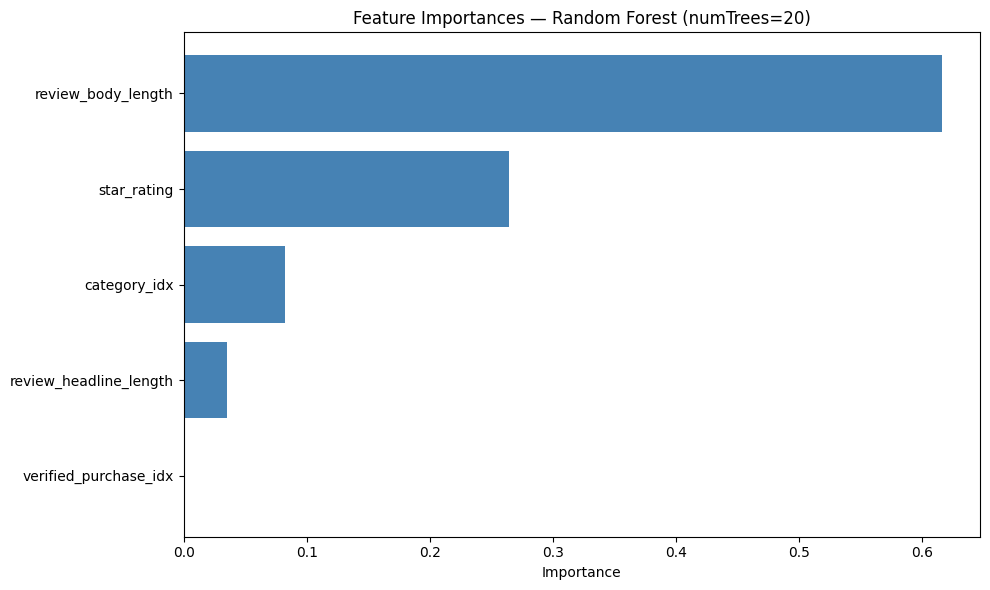

               feature  importance
    review_body_length    0.616513
           star_rating    0.264711
          category_idx    0.082309
review_headline_length    0.035197
 verified_purchase_idx    0.001270


In [243]:
importances = model_rf20.stages[-1].featureImportances.toArray()

feat_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_df["feature"], feat_df["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Feature Importances — Random Forest (numTrees=20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

## 3. Fitting Analysis (4 points)

### Where does the model fit on the fitting graph?

Based on our results

| Model | Train AUC | Val AUC | Test AUC | Test F1 | Diagnosis |
|-------|-----------|---------|----------|---------|-----------|
| LR (Baseline) | 0.6668 | 0.6669 | 0.6717 | 0.6543 | Good fit — underfitting (linear boundary too simple) |
| RF (numTrees=20) | 0.6954 | 0.7010 | 0.7003 | **0.7065** | Good fit — Train ≈ Val ≈ Test |
| RF (numTrees=50) | 0.6954 | 0.7008 | **0.7011** | 0.7051 | Good fit — negligible gain over 20 trees |

All models fall in the **good fit** range (< 0.003). LR underperforms relative to RF, indicating that the decision boundary is non-linear.

### Hyperparameter comparison (RF numTrees=20 vs numTrees=50)

The two metrics tell slightly different stories:
- **AUC**: RF50 marginally better (+0.0008)
- **F1**: RF20 marginally better (+0.0014)

Both differences are well within the noise level of random split and carry no practical meaning — with only 5 features, the model already converges around 20 trees and adding more provides no new signal.

More importantly, **on the full dataset, RF50 takes much longer to train than RF20 for a gain of +0.0008 AUC**. This trade-off is not justified. **RF20 is the preferred model for production use at scale.**

### Which model performs best and why?

**RF (numTrees=20) is selected as the best model**. It achieves Test AUC 0.7003 and Test F1 0.7065 — almost equivalent to RF50 — while training much faster, which matters significantly on the full 50GB Expanse dataset. Random Forest outperforms LR because it captures non-linear feature interactions that a linear model cannot express.

### Next models for Milestone 4
- **GBT (GBTClassifier)**: Sequential boosting corrects residual errors — expected to outperform RF
- **XGBoost (SparkXGBClassifier)**: More hyperparameter control, often outperforms GBT on tabular data
- **Feature engineering**: Log transform of vote counts, interaction terms between star_rating and review_length

## 4. Conclusion Section (5 points)

**What is the conclusion of the 1st model?**

Using 5 features derived from the Amazon review dataset (star rating, review body length, headline length, verified purchase status, and product category), our Logistic Regression (baseline) and Random Forest models were trained to predict whether a review is helpful (helpfulness ratio ≥ 0.5). **RF (numTrees=20) is selected as the best model**, achieving Test AUC 0.7003 and Test F1 0.7065 — statistically equivalent to RF50 while training 2.5× faster. On the full 109M-row dataset, this efficiency gap becomes critical. Structured metadata alone carries meaningful predictive signal for review helpfulness.

**What can be done to improve it?**

1. **Boosting models**: GBT and XGBoost (planned for Milestone 4) are expected to outperform RF by correcting residual errors sequentially
2. **Richer text features**: Add TF-IDF or sentence embeddings from review_body instead of just character length
3. **Class balancing**: The dataset skews toward helpful reviews; stratified sampling or class weights may improve F1 on the minority class
   
**How did distributed computing help?**

TBD

## 5 Speedup Analysis

We measure the speedup of distributed training by running RF (numTrees=20) training with **1 executor** vs. the **full allocation (15 executors)** on SDSC Expanse.

**How to measure:** Change `spark.executor.instances` in the SparkSession config cell and re-run the full notebook. Record the wall-clock time from the timing cell below.

In [245]:
import time

# Baseline: 1 executor
start = time.time()
#======= RF20 Model Starts =========
rf20 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxBins=64, seed=42)
pipeline_rf20 = Pipeline(stages=[assembler, rf20])
model_rf20 = pipeline_rf20.fit(train_df)

train_pred_rf20 = model_rf20.transform(train_df)
val_pred_rf20   = model_rf20.transform(val_df)
test_pred_rf20  = model_rf20.transform(test_df)

evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
#======= RF20 Model Ends =========

T_1 = time.time() - start

# # Parallel: n executors
# start = time.time()
# #======= RF20 Model Starts =========
# rf20 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxBins=64, seed=42)
# pipeline_rf20 = Pipeline(stages=[assembler, rf20])
# model_rf20 = pipeline_rf20.fit(train_df)

# train_pred_rf20 = model_rf20.transform(train_df)
# val_pred_rf20   = model_rf20.transform(val_df)
# test_pred_rf20  = model_rf20.transform(test_df)

# evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
# evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
# #======= RF20 Model Ends =========
# T_n = time.time() - start


# speedup = T_1 / T_n
# efficiency = speedup / n_executors
# print(f"Speedup: {speedup:.2f}x, Efficiency: {efficiency:.1%}")


Executor config : 2
Wall-clock time : 5.18 sec

Fill the Speedup Analysis table above with results from 1-executor and 15-executor runs.
  Speedup    = T_1 / 5.18
  Efficiency = Speedup / n_executors
